In [47]:
import pandas as pd
df = pd.read_csv("global_weather_data_2015_2024.csv", low_memory=False)
df.shape
df

,date,tavg,tmin,tmax,prcp,snow,wdir,wspd,wpgt,pres,tsun,city,country
0,2015-01-02 00:00:00,11.1,NaN,NaN,NaN,NaN,NaN,5.4,NaN,NaN,NaN,Islamabad,Pakistan
1,2015-01-03 00:00:00,11.3,6.7,18.8,NaN,NaN,NaN,1.4,NaN,NaN,NaN,Islamabad,Pakistan
2,2015-01-04 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Islamabad,Pakistan
3,2015-01-05 00:00:00,10.9,5.7,17.8,NaN,NaN,NaN,7.4,NaN,NaN,NaN,Islamabad,Pakistan
4,2015-01-06 00:00:00,11.1,NaN,NaN,NaN,NaN,NaN,8.7,NaN,NaN,NaN,Islamabad,Pakistan
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29187,2024-12-24 00:00:00,12.7,10.4,15.4,0.3,NaN,NaN,9.4,NaN,1018.0,NaN,Los Angeles,USA
29188,2024-12-25 00:00:00,14.0,10.4,17.6,0.0,NaN,NaN,8.3,NaN,1017.9,NaN,Los Angeles,USA
29189,2024-12-26 00:00:00,13.2,7.6,18.1,0.0,NaN,NaN,7.6,NaN,1017.8,NaN,Los Angeles,USA
29190,2024-12-27 00:00:00,12.2,9.2,15.9,0.0,NaN,NaN,7.2,NaN,1018.4,NaN,Los Angeles,USA


In [48]:
df = df[df['city'] == 'Islamabad'].copy()
df = df[['date', 'wspd', 'tavg']]
df


,date,wspd,tavg
0,2015-01-02 00:00:00,5.4,11.1
1,2015-01-03 00:00:00,1.4,11.3
2,2015-01-04 00:00:00,NaN,NaN
3,2015-01-05 00:00:00,7.4,10.9
4,2015-01-06 00:00:00,8.7,11.1
...,...,...,...
3644,2024-12-24 00:00:00,5.6,9.0
3645,2024-12-25 00:00:00,6.3,10.2
3646,2024-12-26 00:00:00,4.1,11.5
3647,2024-12-27 00:00:00,6.5,9.5


In [49]:
df.isnull().sum()
df = df.dropna()

In [50]:
import datetime as dt
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['Date Ordinal'] = df['date'].map(dt.datetime.toordinal)
df

C:\Users\DELL\AppData\Local\Temp\ipykernel_18740\1307201990.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date'] = pd.to_datetime(df['date'], errors='coerce')
C:\Users\DELL\AppData\Local\Temp\ipykernel_18740\1307201990.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date Ordinal'] = df['date'].map(dt.datetime.toordinal)


,date,wspd,tavg,Date Ordinal
0,2015-01-02,5.4,11.1,735600
1,2015-01-03,1.4,11.3,735601
3,2015-01-05,7.4,10.9,735603
4,2015-01-06,8.7,11.1,735604
7,2015-01-09,5.0,10.6,735607
...,...,...,...,...
3644,2024-12-24,5.6,9.0,739244
3645,2024-12-25,6.3,10.2,739245
3646,2024-12-26,4.1,11.5,739246
3647,2024-12-27,6.5,9.5,739247


C:\Users\DELL\AppData\Local\Temp\ipykernel_18740\378080376.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['date'].dt.year


Coefficients [intercept, date, wind speed]: [-6.54017172e+02  9.05909945e-04  7.15998705e-01]
Test Mean Squared Error: 41.8490


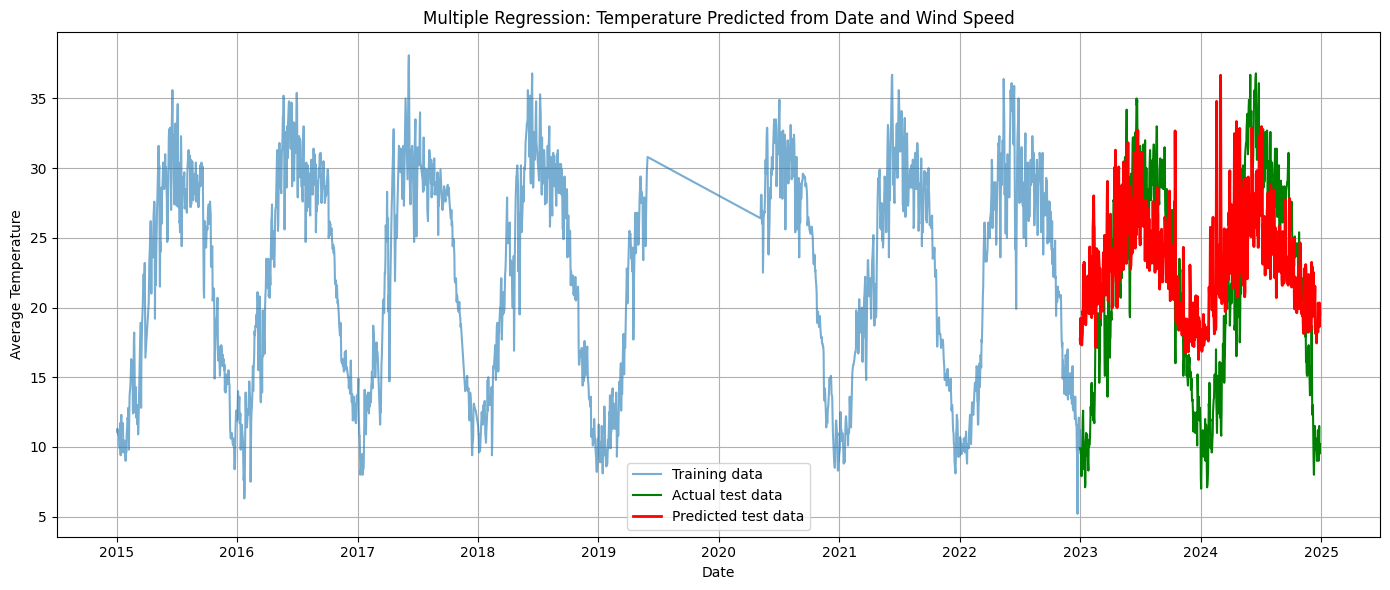

In [51]:
import numpy as np

import matplotlib.pyplot as plt

# Create the year column from the existing date column
df['Year'] = df['date'].dt.year

train_df = df[df['Year'] <= 2022].copy()
test_df = df[df['Year'] > 2022].copy()

def train_multiple_regression(data):
    """Train a multiple linear regression model using Date and Wind Speed."""
    X = data[['Date Ordinal', 'wspd']].to_numpy(dtype=float)
    y = data['tavg'].to_numpy(dtype=float)

    # Add an intercept column and solve using least squares
    X_design = np.column_stack([np.ones(len(X)), X])
    coefficients = np.linalg.lstsq(X_design, y, rcond=None)[0]

    return coefficients

def predict_temperatures(data, coefficients):
    """Predict temperatures for a dataframe."""
    X = data[['Date Ordinal', 'wspd']].to_numpy(dtype=float)
    X_design = np.column_stack([np.ones(len(X)), X])
    return X_design @ coefficients

# Train and predict
coefficients = train_multiple_regression(train_df)
test_predictions = predict_temperatures(test_df, coefficients)

# Calculate Mean Squared Error
mse = np.mean((test_df['tavg'].to_numpy() - test_predictions) ** 2)
print("Coefficients [intercept, date, wind speed]:", coefficients)
print(f"Test Mean Squared Error: {mse:.4f}")

# Visualization
plt.figure(figsize=(14, 6))
plt.plot(train_df['date'], train_df['tavg'], label='Training data', alpha=0.6)
plt.plot(test_df['date'], test_df['tavg'], label='Actual test data', color='green')
plt.plot(test_df['date'], test_predictions, label='Predicted test data',
         color='red', linewidth=2)

plt.xlabel('Date')
plt.ylabel('Average Temperature')
plt.title('Multiple Regression: Temperature Predicted from Date and Wind Speed')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()